In [1]:
# NOTE:
# if your want to use your own video
# When you run the code, you can observe pixel coordinates (e.g., using mouse movement).
# Based on those coordinates, adjust the values in the region_of_interest() function
# so the selected area correctly matches the lane region in your video.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def make_coordinates(image, line_parameters):
    slope, intercept = line_parameters
    y1 = image.shape[0]                # bottom of the image
    y2 = int(y1 * (3/5))               # top position for the line
    x1 = int((y1 - intercept) / slope) # bottom x
    x2 = int((y2 - intercept) / slope) # top x
    return np.array([x1, y1, x2, y2])
    
def average_slope_intercept(image, lines):
    left_fit = []
    right_fit = []
    if lines is None:
        return None  # No lines detected
    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        parameters = np.polyfit((x1, x2), (y1, y2), 1)
        slope, intercept = parameters
        if slope < 0:
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))
    left_line = None
    right_line = None
    if left_fit:
        left_fit_average = np.average(left_fit, axis=0)
        left_line = make_coordinates(image, left_fit_average)
    if right_fit:
        right_fit_average = np.average(right_fit, axis=0)
        right_line = make_coordinates(image, right_fit_average)
    lines = []
    if left_line is not None:
        lines.append(left_line)
    if right_line is not None:
        lines.append(right_line)
    if lines:
        return np.array(lines)
    else:
        return None

def canny(image):
    gray=cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur= cv2.GaussianBlur(gray, (5,5),0)
    canny=cv2.Canny(blur,50,150)
    return canny

def display_of_lines(image, lines):
    line_image= np.zeros_like(image)
    if lines is not None:
        for x1, y1, x2, y2 in lines:
            cv2.line(line_image, (x1, y1), (x2,y2), (255,0,0), 10) #(var, point, point, color of line, thikness of line)
    return line_image

def region_of_interest(image):
    height=image.shape[0]
    polygons=np.array([
        [(200,height), (1110, height), (550,250)]
    ])
    mask=np.zeros_like(image)
    cv2.fillPoly(mask, polygons, 255)
    masked_image= cv2.bitwise_and(image, mask)
    return masked_image
    
cap = cv2.VideoCapture("test0.mp4")
# Create a resizable window
cv2.namedWindow("result", cv2.WINDOW_NORMAL)
cv2.resizeWindow("result", 800, 600)  # width=800, height=600
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    # Lane detection steps
    canny_image = canny(frame)
    cropped_image = region_of_interest(canny_image)
    lines = cv2.HoughLinesP(cropped_image, 2, np.pi/180, 70,np.array([]), minLineLength=40, maxLineGap=5)
    averaged_lines = average_slope_intercept(frame, lines)
    line_image = display_of_lines(frame, averaged_lines)
    combo_image = cv2.addWeighted(frame, 0.8, line_image, 1, 1)
    cv2.imshow("result", combo_image)
    if cv2.waitKey(1) & 0xFF == ord ('q'):
        break
cap.release()
cv2.destroyAllWindows()


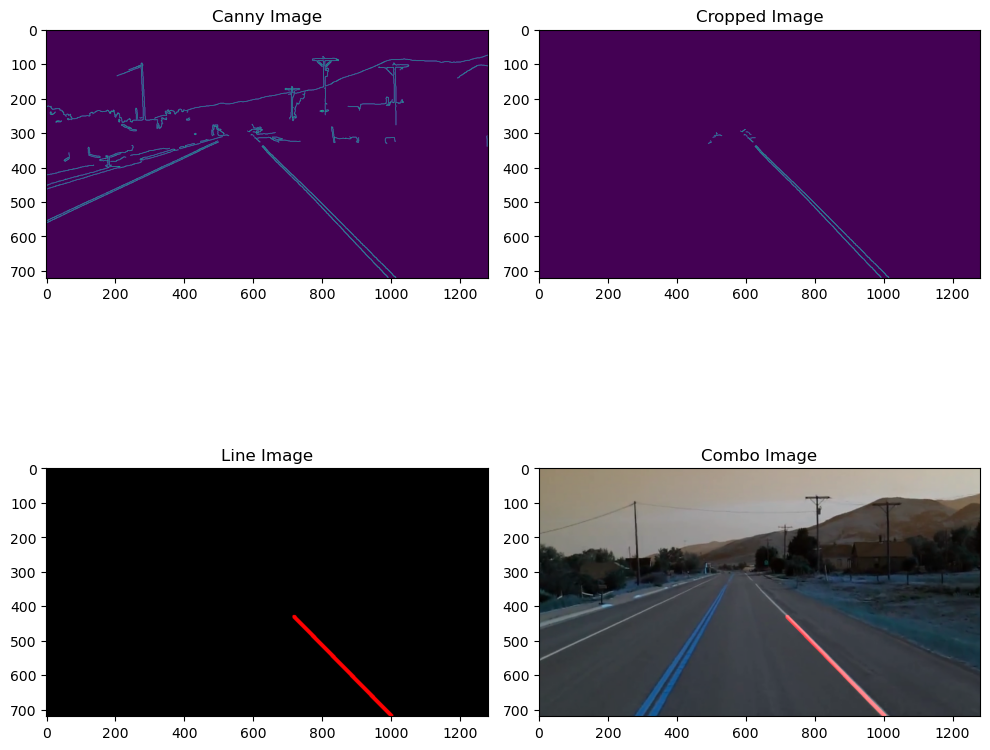

In [5]:
import matplotlib.pyplot as plt

# Use your actual images
images = [canny_image, cropped_image, line_image, combo_image]
titles = ["Canny Image", "Cropped Image", "Line Image", "Combo Image"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("on")  # show axes

plt.tight_layout()
plt.show()
